# Rate-of-Change Matrix: IKE / R34 / Pmin / Vmax by ET Phase (North Atlantic vs. West Pacific)

2x2 grid of box plots, each panel one variable's 6-hour rate of change, comparing North
Atlantic against West Pacific directly within each ET phase (Early Tropical vs. Pre-ET,
<48hr from transition).

## Paths
See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`. 

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ike_climatology import config
from ike_climatology.shear_rate_of_change import load_master_dataframe_masked
from ike_climatology.rate_of_change_matrix import (
    VariableSpec,
    assign_phase,
    add_rate_of_change_diffs,
    PHASE_ORDER,
)


## Data extraction

Only North Atlantic and West Pacific, matching the source script.

In [4]:
BASINS = ["North Atlantic", "West Pacific"]

master_df = load_master_dataframe_masked(
    basins=BASINS,
    ibtracs_file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

print(f"{len(master_df)} qualifying (tropical-phase) timesteps.")


--- Loading Data (2004-2024) ---
    - North Atlantic: filtered out 2 non-genesis storms.
    - West Pacific: filtered out 16 non-genesis storms.
15658 qualifying (tropical-phase) timesteps.


## Variable configs

`column` is the actual DataFrame column diffed; `label` is descriptive only (not used
below, kept for parity with the source script).

In [5]:
VARIABLES = {
    "IKE":  VariableSpec("total_ike_tj", "TJ",  "6-hour", 1),
    "R34":  VariableSpec("r34_km",       "km",  "6-hour", 1),
    "Pmin": VariableSpec("pmin_mb",      "mb",  "6-hour", 1),
    "Vmax": VariableSpec("vmax_kts",     "kts", "6-hour", 1),
}


## Plotting function

In [6]:
BASIN_PALETTE = {
    "South Pacific": "royalblue", "South Indian": "darkblue",
    "North Atlantic": "tomato", "West Pacific": "maroon",
}


def plot_metric_matrix(plot_df, variables, basins, output_dir, *, start_year, end_year, filter_label, file_tag, n_cols=2):
    print(f"\n--- Generating matrix ({filter_label}) ---")

    basins = list(basins)
    palette = {b: BASIN_PALETTE.get(b) for b in basins}

    n_vars = len(variables)
    n_rows = (n_vars + n_cols - 1) // n_cols

    fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(18, 11), sharex=False, constrained_layout=True)
    axes = [axes_grid] if n_vars == 1 else list(np.asarray(axes_grid).ravel())

    var_items = list(variables.items())
    bottom_indices = {idx for idx in range(n_vars) if idx + n_cols >= n_vars}

    for idx, (var_name, spec) in enumerate(var_items):
        ax = axes[idx]
        panel = plot_df[plot_df["basin"].isin(basins)].dropna(subset=[spec.diff_col])

        if panel.empty:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center",
                    fontsize=14, color="gray")
            continue

        sns.boxplot(
            data=panel, x="phase", y=spec.diff_col, hue="basin",
            order=PHASE_ORDER, hue_order=basins, palette=palette,
            showfliers=False, width=0.7, linewidth=1.2, ax=ax,
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.grid(True, axis="y", linestyle=":", alpha=0.5)
        ax.set_ylim(-30, 30)

        if var_name == "Pmin":
            ax.invert_yaxis()
        if var_name == "R34":
            ax.set_ylim(-60, 60)

        ax.set_ylabel(f"\u0394{var_name} Per 6 h ({spec.units})", fontsize=14, fontweight="bold")

        if idx == 0:
            ax.legend(title="Basin", loc="upper left", frameon=True)
        else:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        ax.tick_params(axis="x", labelsize=12)
        if idx in bottom_indices:
            ax.set_xlabel("Storm Phase", fontsize=14, fontweight="bold")
        else:
            ax.set_xlabel("")

    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"6-hour Rate of Change by Storm Phase, {filter_label.title()} ({start_year}\u2013{end_year})",
        fontsize=18, fontweight="bold",
    )

    filename = f"6hr_rateofchange4basin_{file_tag}.png"
    path = os.path.join(output_dir, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"      saved: {filename}")
    return path


## Generate both scenarios (with and without land interaction)


--- Generating matrix (no land interaction) ---


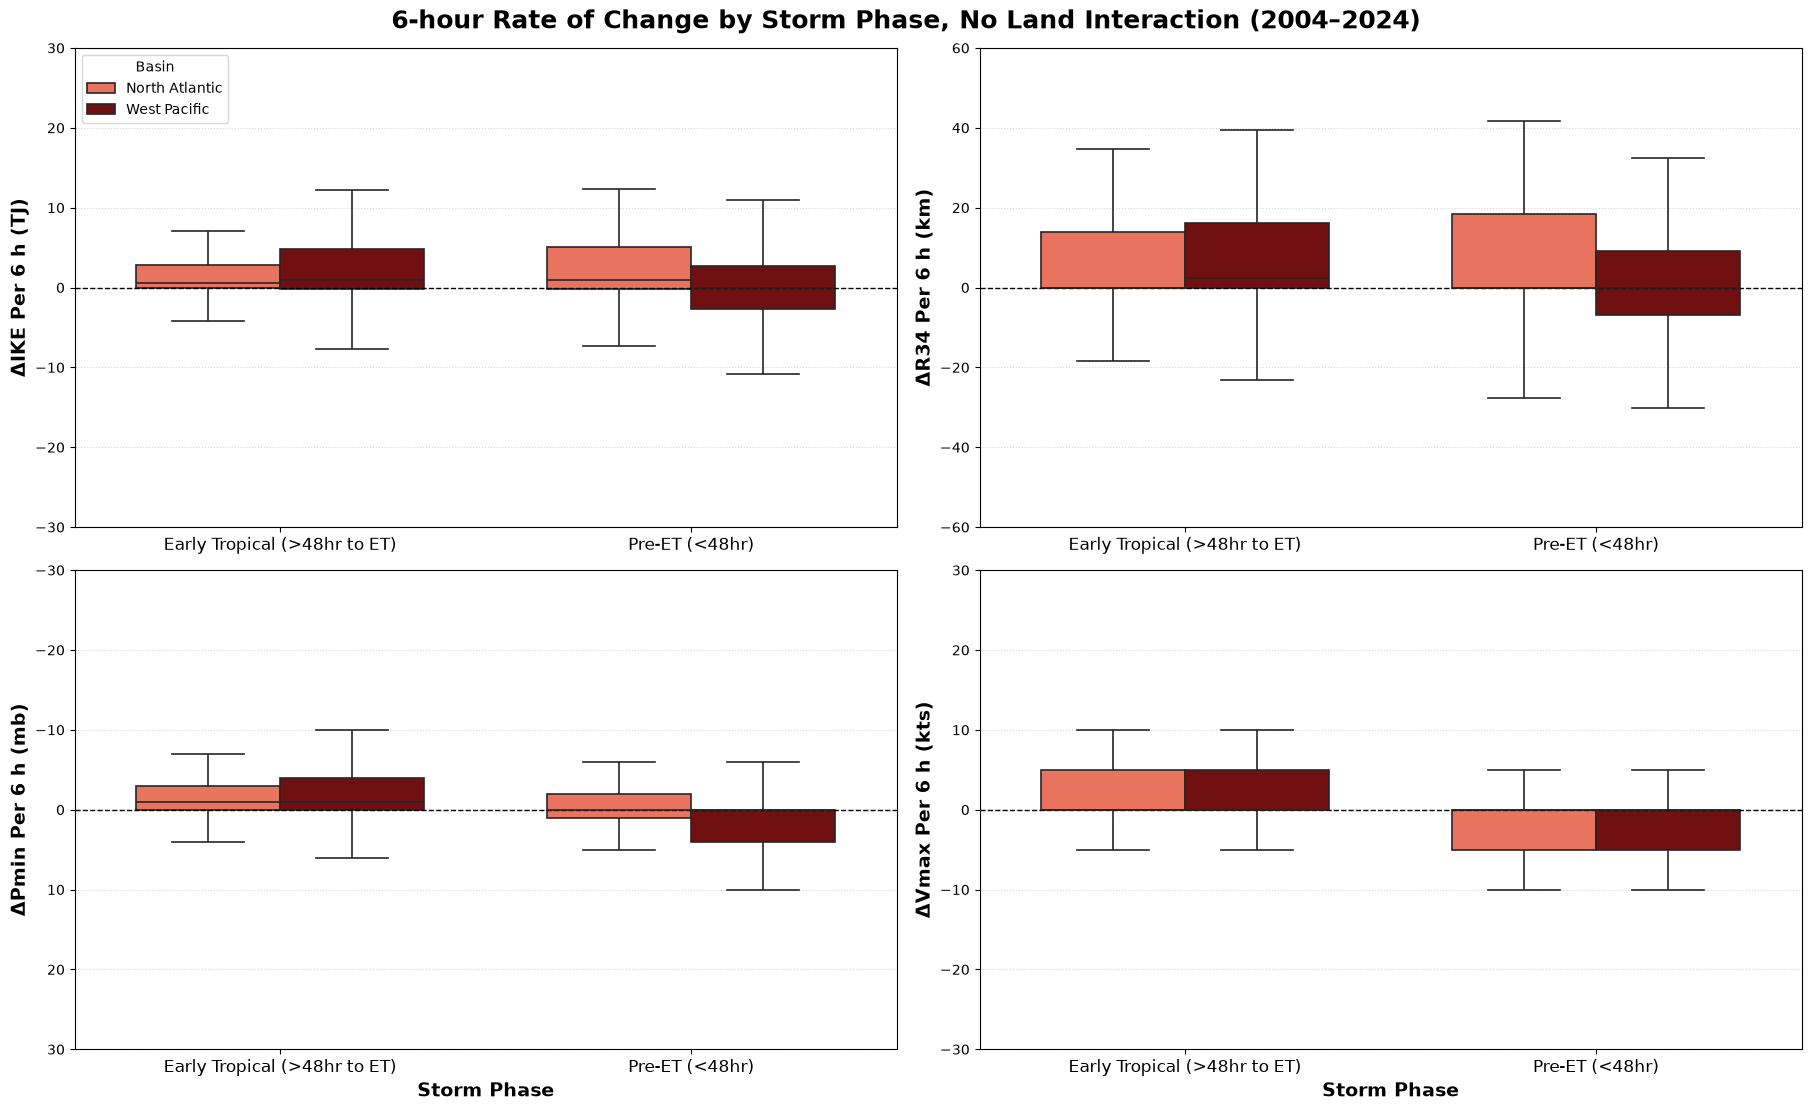

      saved: 6hr_rateofchange4basin_no_land.png

--- Generating matrix (all storms) ---


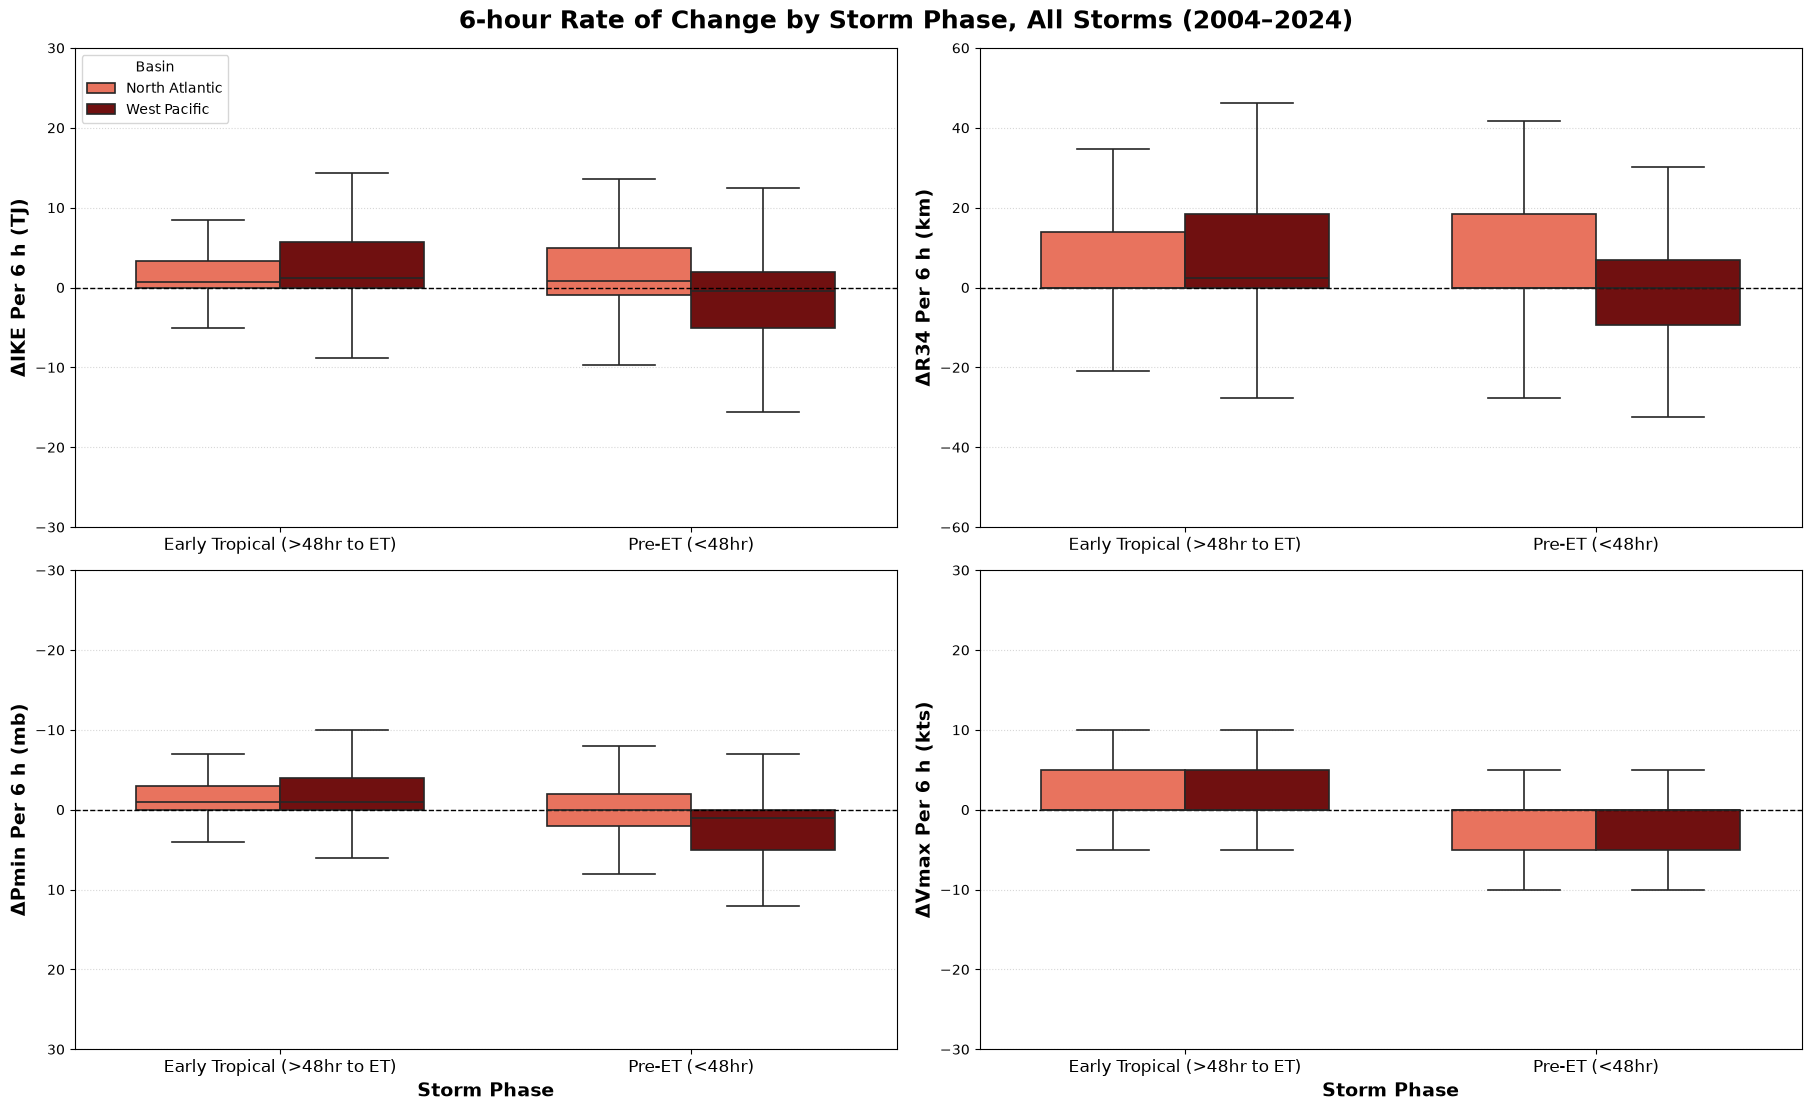

      saved: 6hr_rateofchange4basin_all.png

--- Done ---


In [7]:
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
basin_names = BASINS

scenarios = [
    (True, "no land interaction", "no_land"),
    (False, "all storms", "all"),
]

for exclude_land, label, tag in scenarios:
    analysis_df = master_df.copy()
    if exclude_land:
        landfalling = (
            analysis_df.loc[analysis_df["had_landfall"], ["basin", "storm_year", "storm_name"]]
            .drop_duplicates()
        )
        keys = ["basin", "storm_year", "storm_name"]
        mask = ~analysis_df.set_index(keys).index.isin(landfalling.set_index(keys).index)
        analysis_df = analysis_df[mask]

    plot_df = add_rate_of_change_diffs(assign_phase(analysis_df), VARIABLES)

    plot_metric_matrix(
        plot_df, VARIABLES, basins=basin_names, output_dir=config.BASE_OUTPUT_DIR,
        start_year=config.START_YEAR, end_year=config.END_YEAR,
        filter_label=label, file_tag=tag,
    )


print("\n--- Done ---")
